# Best vs Most Popular Destinations
Compare rating rank vs popularity to spot under-recognized and over-popular destinations.

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8")

In [14]:
# Configuration
INPUT_FILE = os.getenv("INPUT_FILE", "Processed_Reviews.csv")
MIN_REVIEWS_DEST = 20

In [15]:
# Load dataset
df = pd.read_csv(INPUT_FILE)

print(f"Loaded: {INPUT_FILE}")
print("Shape:", df.shape)

Loaded: Processed_Reviews.csv
Shape: (16156, 41)


In [16]:
# Validate required columns
required_cols = [
    "Location_Name",
    "Location_Avg_Rating",
    "Location_Review_Count",
    "Rank_By_Rating",
    "Rank_By_Popularity",
    "Popularity_Quality_Gap"
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

In [17]:
# Destination-level unique table
destinations = (
    df[[
        "Location_Name",
        "Location_Avg_Rating",
        "Location_Review_Count",
        "Rank_By_Rating",
        "Rank_By_Popularity",
        "Popularity_Quality_Gap"
    ]]
    .drop_duplicates()
    .copy()
)
destinations = destinations[destinations["Location_Review_Count"] >= MIN_REVIEWS_DEST].copy()

print(f"\nDestinations with at least {MIN_REVIEWS_DEST} reviews: {len(destinations)}")


Destinations with at least 20 reviews: 76


In [18]:
# Best rated destinations
best_rated = destinations.sort_values(by=["Location_Avg_Rating", "Location_Review_Count"], ascending=[False, False]).head(15)
print("\n=== Top 15 Best Rated Destinations ===")
print(best_rated)


=== Top 15 Best Rated Destinations ===
                                   Location_Name  Location_Avg_Rating  \
10436               Kalametiya Eco Bird Watching             4.992424   
9231                       Bundala National Park             4.698413   
10287                    Udawalawe National Park             4.677852   
8390                    Community Tsunami Museum             4.665563   
7421          Sigiriya The Ancient Rock Fortress             4.645614   
4227                      Handunugoda Tea Estate             4.638158   
187                                Bentota Beach             4.587983   
5585                     Royal Botanical Gardens             4.572700   
13870                                  Mihintale             4.562724   
1950                            Passikudah Beach             4.562500   
9815                        Kumana National Park             4.542857   
14574                  Kelaniya Raja Maha Vihara             4.540107   
6719       

In [19]:
# Most popular destinations
most_popular = destinations.sort_values(by=["Location_Review_Count", "Location_Avg_Rating"], ascending=[False, False]).head(15)
print("\n=== Top 15 Most Popular Destinations ===")
print(most_popular)


=== Top 15 Most Popular Destinations ===
                          Location_Name  Location_Avg_Rating  \
10732      Pinnawala Elephant Orphanage             3.420054   
5585            Royal Botanical Gardens             4.572700   
6956                        Polonnaruwa             4.423423   
11667            Wilpattu National Park             4.076687   
15345              Dambulla Cave Temple             4.436137   
3085              Bluefield Tea Gardens             4.222930   
8778                    Sigiriya Museum             3.633758   
7783                  Ceylon Tea Museum             4.075410   
4227             Handunugoda Tea Estate             4.638158   
8390           Community Tsunami Museum             4.665563   
8088            Colombo National Museum             4.099338   
3661               Glenloch Tea Factory             3.824503   
4531                  Pedro Tea Factory             3.791391   
2366                         Kandy Lake             3.940199  

In [20]:
# Over-popular vs under-recognized
over_popular = destinations.sort_values(by="Popularity_Quality_Gap", ascending=False).head(15)
under_recognized = destinations.sort_values(by="Popularity_Quality_Gap", ascending=True).head(15)

print("\n=== Top 15 Over-Popular Destinations ===")
print(over_popular)

print("\n=== Top 15 Under-Recognized Destinations ===")
print(under_recognized)


=== Top 15 Over-Popular Destinations ===
                                   Location_Name  Location_Avg_Rating  \
10436               Kalametiya Eco Bird Watching             4.992424   
9815                        Kumana National Park             4.542857   
10287                    Udawalawe National Park             4.677852   
8692   Martin Wickramasinghe Folk Museum Complex             4.511628   
12067                             Diyaluma Falls             4.488372   
1950                            Passikudah Beach             4.562500   
9231                       Bundala National Park             4.698413   
2667                                  Tissa Wewa             4.428571   
7289                   Ritigala Forest Monastery             4.446970   
14574                  Kelaniya Raja Maha Vihara             4.540107   
14383                          Abhayagiri Dagaba             4.302083   
10568                   Minneriya Tusker Safaris             4.341463   
1785     

In [21]:
# Balanced high-quality and popular destinations
balanced_best = destinations[
    (destinations["Rank_By_Rating"] <= 15) & (destinations["Rank_By_Popularity"] <= 15)
].sort_values(by=["Rank_By_Rating", "Rank_By_Popularity"])

print("\n=== Destinations that are both Highly Rated and Popular ===")
print(balanced_best)


=== Destinations that are both Highly Rated and Popular ===
                           Location_Name  Location_Avg_Rating  \
8390            Community Tsunami Museum             4.665563   
7421  Sigiriya The Ancient Rock Fortress             4.645614   
4227              Handunugoda Tea Estate             4.638158   
5585             Royal Botanical Gardens             4.572700   

      Location_Review_Count  Rank_By_Rating  Rank_By_Popularity  \
8390                    302             4.0                 9.0   
7421                    285             5.0                15.0   
4227                    304             6.0                 8.0   
5585                    337             8.0                 2.0   

      Popularity_Quality_Gap  
8390                     5.0  
7421                    10.0  
4227                     2.0  
5585                    -6.0  


In [22]:
# Destination rank comparison table
comparison_table = destinations.sort_values(by=["Rank_By_Rating", "Rank_By_Popularity"])
print("\n=== Destination Rank Comparison Table ===")
print(comparison_table.head(30))


=== Destination Rank Comparison Table ===
                                   Location_Name  Location_Avg_Rating  \
10436               Kalametiya Eco Bird Watching             4.992424   
9231                       Bundala National Park             4.698413   
10287                    Udawalawe National Park             4.677852   
8390                    Community Tsunami Museum             4.665563   
7421          Sigiriya The Ancient Rock Fortress             4.645614   
4227                      Handunugoda Tea Estate             4.638158   
187                                Bentota Beach             4.587983   
5585                     Royal Botanical Gardens             4.572700   
13870                                  Mihintale             4.562724   
1950                            Passikudah Beach             4.562500   
9815                        Kumana National Park             4.542857   
14574                  Kelaniya Raja Maha Vihara             4.540107   
6719    

C:\Users\abaiy\AppData\Local\Temp\ipykernel_14900\4133406409.py:8: UserWarning: Glyph 146 (\x92) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\abaiy\Group-J---Research-Paper\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


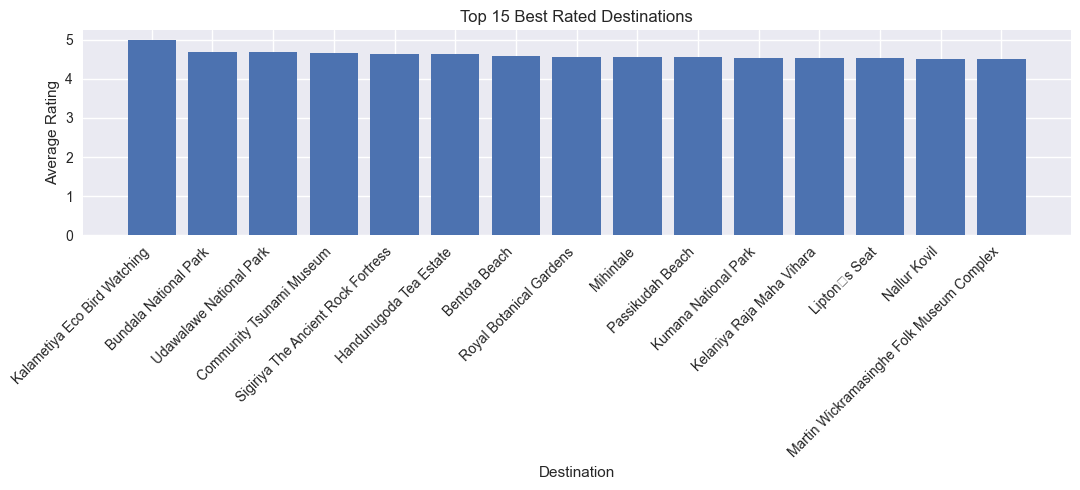

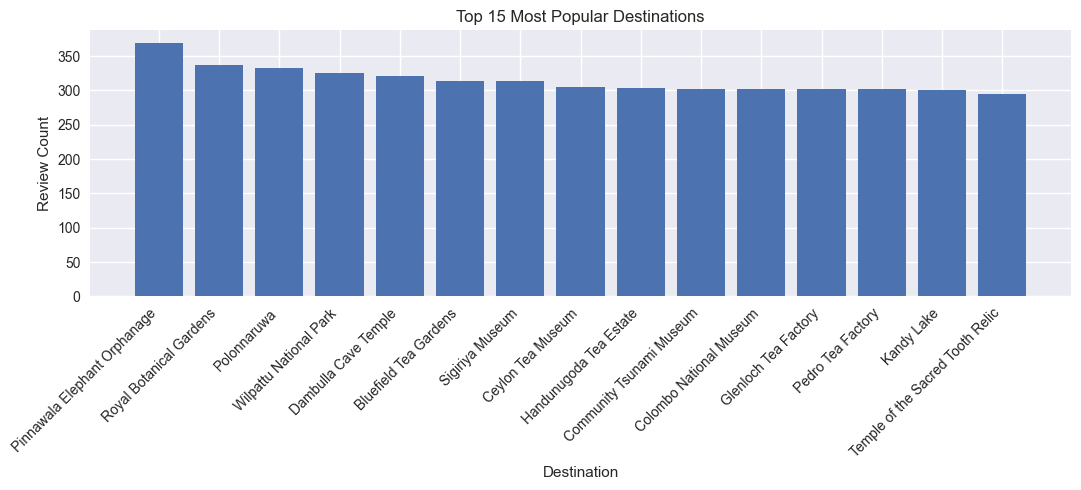

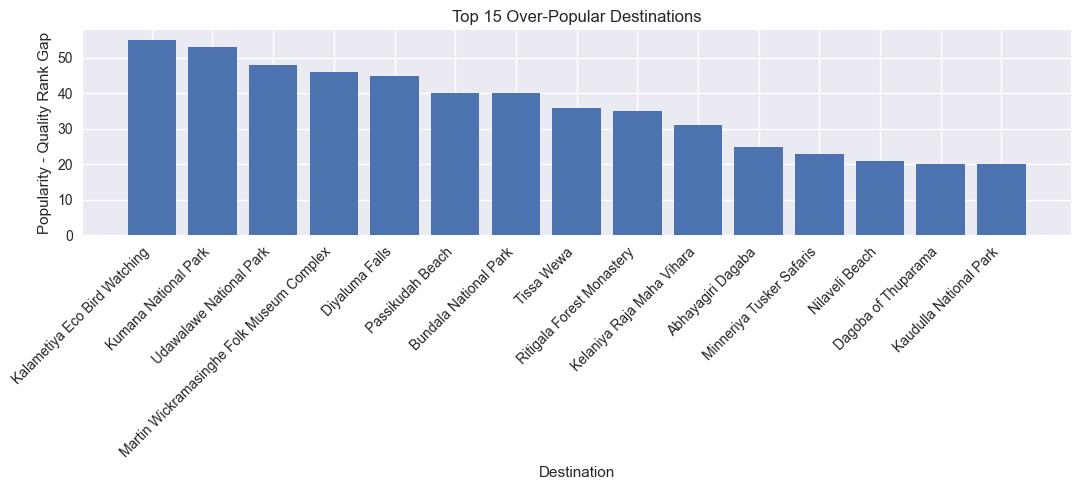

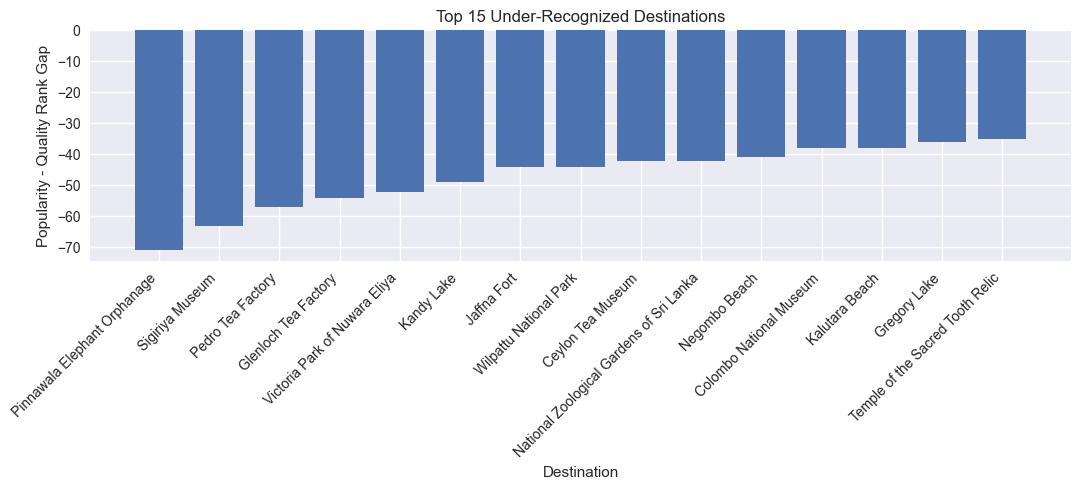

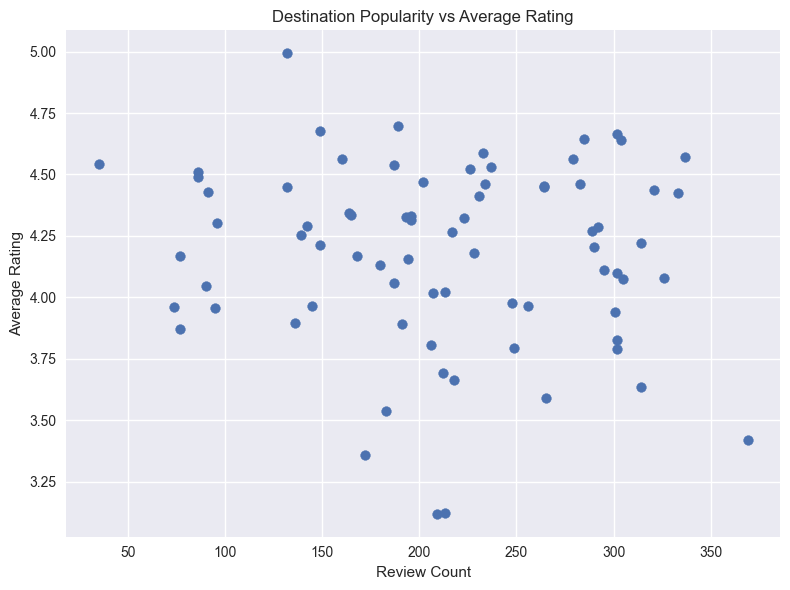

In [23]:
# Plots
plt.figure(figsize=(11, 5))
plt.bar(best_rated["Location_Name"], best_rated["Location_Avg_Rating"])
plt.title("Top 15 Best Rated Destinations")
plt.xlabel("Destination")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(most_popular["Location_Name"], most_popular["Location_Review_Count"])
plt.title("Top 15 Most Popular Destinations")
plt.xlabel("Destination")
plt.ylabel("Review Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(over_popular["Location_Name"], over_popular["Popularity_Quality_Gap"])
plt.title("Top 15 Over-Popular Destinations")
plt.xlabel("Destination")
plt.ylabel("Popularity - Quality Rank Gap")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(under_recognized["Location_Name"], under_recognized["Popularity_Quality_Gap"])
plt.title("Top 15 Under-Recognized Destinations")
plt.xlabel("Destination")
plt.ylabel("Popularity - Quality Rank Gap")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(destinations["Location_Review_Count"], destinations["Location_Avg_Rating"])
plt.title("Destination Popularity vs Average Rating")
plt.xlabel("Review Count")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

In [24]:
# Save outputs
best_rated.to_csv("best_rated_destinations.csv", index=False)
most_popular.to_csv("most_popular_destinations.csv", index=False)
over_popular.to_csv("over_popular_destinations.csv", index=False)
under_recognized.to_csv("under_recognized_destinations.csv", index=False)
balanced_best.to_csv("balanced_best_destinations.csv", index=False)
comparison_table.to_csv("destination_rank_comparison.csv", index=False)

print("\n✅ Best vs Most Popular destination analysis complete.")
print("Saved files:")
print("- best_rated_destinations.csv")
print("- most_popular_destinations.csv")
print("- over_popular_destinations.csv")
print("- under_recognized_destinations.csv")
print("- balanced_best_destinations.csv")
print("- destination_rank_comparison.csv")


✅ Best vs Most Popular destination analysis complete.
Saved files:
- best_rated_destinations.csv
- most_popular_destinations.csv
- over_popular_destinations.csv
- under_recognized_destinations.csv
- balanced_best_destinations.csv
- destination_rank_comparison.csv
